# Projeto 3 — Previsão de Preços de Passagens Aéreas

Projeto 3: Regressão Não-Linear (Ensembles)
Tema: Previsão de Preços de Passagens Aéreas.

Dataset Sugerido: Flight Price Prediction. https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

Desafio: Capturar relações complexas e não-lineares (ex: dias até o voo vs. preço).

Conceitos-Chave: Random Forest Regressor, XGBoost, comparação de modelos baseados em árvore vs. lineares.

### Importando libraries necessárias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Carregando o dataset
db = pd.read_csv('business.csv')
de = pd.read_csv('economy.csv')

db['class'] = 'Business'
de['class'] = 'Economy'

df = pd.concat([db, de])

In [4]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612",Business
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612",Business
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220",Business
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450",Business
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690",Business


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300261 entries, 0 to 206773
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        300261 non-null  object
 1   airline     300261 non-null  object
 2   ch_code     300261 non-null  object
 3   num_code    300261 non-null  int64 
 4   dep_time    300261 non-null  object
 5   from        300261 non-null  object
 6   time_taken  300261 non-null  object
 7   stop        300261 non-null  object
 8   arr_time    300261 non-null  object
 9   to          300261 non-null  object
 10  price       300261 non-null  object
 11  class       300261 non-null  object
dtypes: int64(1), object(11)
memory usage: 29.8+ MB


In [6]:
df.describe()

,num_code
count,300261.000000
mean,1417.771709
std,1974.514439
min,101.000000
25%,637.000000
50%,818.000000
75%,927.000000
max,9991.000000


In [7]:
df.isnull().sum()

date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
class         0
dtype: int64

### Por que a raw data aparece assim no `info()` e `describe()`?

**Por que `price` ficou como `object` (texto) em vez de número?**
O pandas infere o tipo de cada coluna com base no que está escrito nela. Como os valores vêm no formato `"25,612"`, a vírgula do milhar é interpretada como um caractere não-numérico — o pandas não sabe que ali é um separador, só vê que não é um dígito válido. Por isso `price` permanece como `object` até limpar a vírgula e converter para numérico.

**Por que `describe()` só mostrou a coluna `num_code`?**
Por padrão, `describe()` resume apenas colunas numéricas. Como praticamente todas as outras colunas (`price`, `time_taken`, `stop` etc.) ainda estão como `object`, elas ficam de fora do resumo estatístico até serem convertidas.

**Por que o índice ficou `0 to 206773` em vez de `0 to 300260`?**
Cada CSV lido separadamente com `read_csv()` ganha seu próprio índice começando do zero (`business.csv`: 0, 1, 2...; `economy.csv`: 0, 1, 2...). Ao concatenar com `pd.concat()`, o pandas **mantém os índices originais** de cada DataFrame em vez de gerar um novo — resultando em índices duplicados (duas linhas diferentes podem ter o mesmo índice). Resolvido usando `ignore_index=True` no `concat()`.

In [8]:
df = pd.concat([db, de], ignore_index=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        300261 non-null  object
 1   airline     300261 non-null  object
 2   ch_code     300261 non-null  object
 3   num_code    300261 non-null  int64 
 4   dep_time    300261 non-null  object
 5   from        300261 non-null  object
 6   time_taken  300261 non-null  object
 7   stop        300261 non-null  object
 8   arr_time    300261 non-null  object
 9   to          300261 non-null  object
 10  price       300261 non-null  object
 11  class       300261 non-null  object
dtypes: int64(1), object(11)
memory usage: 27.5+ MB


In [10]:
df_clean = pd.read_csv('Clean_Dataset.csv')

In [11]:
df_clean.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [12]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


## Conclusões: Raw Data vs. Clean Dataset

Ao explorar a raw data (`business.csv` + `economy.csv` concatenados), identificamos vários desafios de formatação que precisariam ser tratados antes de qualquer modelagem:

- **`price`**: vem como texto com vírgula de milhar (ex: `"25,612"`), impedindo operações numéricas diretas.
- **`stop`**: contém lixo de formatação (quebras de linha e tabulações, ex: `"1-stop\n\t\t\t..."`).
- **`date`**: é uma data completa (`"11-02-2022"`), mas o que importa para o modelo é a **antecedência da compra** — a diferença entre a data do voo e a data da pesquisa.
- **`time_taken`**: string tipo `"02h 00m"`, precisa virar duração em horas decimais.
- **`dep_time`/`arr_time`**: horários exatos (`"18:00"`) que precisam ser agrupados em faixas do dia (`Morning`, `Evening`, `Night`...), pois o horário exato é ruidoso demais para generalizar.
- Ao concatenar `business.csv` e `economy.csv` com `pd.concat()`, o índice original de cada arquivo foi preservado, gerando índices duplicados — resolvido com `ignore_index=True`.

O `Clean_Dataset.csv` já resolve todos esses pontos: `price` como `int64`, `duration` já em horas decimais, `days_left` já calculado, `departure_time`/`arrival_time` já em faixas categóricas. Duas observações que corrigem expectativas do planejamento inicial:

- `stops` **não** foi codificado como inteiro — continua categórico (`"zero"`, `"one"`, `"two_or_more"`).
- O Clean Dataset tem **300.153** linhas contra **300.261** da raw combinada (diferença de 108 linhas, possivelmente remoção de duplicatas/outliers no tratamento original — não investigada aqui).

O Clean Dataset também traz uma coluna `Unnamed: 0`, resquício do índice salvo sem `index=False` na geração do arquivo — sem valor preditivo, será descartada na etapa de modelagem.

**Decisão:** a partir daqui, todas as etapas de EDA e modelagem usarão o `Clean_Dataset.csv`, já que ele resolve os problemas de formatação da raw mantendo a mesma informação semântica.

# EDA

## Gráfico 1 — days_left × price por classe



Como o days_left tem muitos valores únicos (1 a ~50 dias), plotar todos os pontos brutos (scatter) fica poluído. É melhor agrupar por days_left e class, calculando o preço médio de cada grupo — isso já é familiar? (dica: groupby)

Depois de agrupar, você usa sns.lineplot() (ou sns.relplot(kind="line")) passando days_left no eixo x, price no eixo y, e usa o parâmetro hue pra separar por class.

In [14]:
df_clean.groupby(['days_left', 'class'])

In [15]:
df_clean.groupby(['days_left', 'class'])['price'].mean()

days_left  class   
1          Business    65169.312030
           Economy     14613.179410
2          Business    60455.848506
           Economy     13980.828244
3          Business    60313.822331
                           ...     
47         Economy      4669.652956
48         Business    51558.758230
           Economy      4717.688994
49         Business    51124.505820
           Economy      4750.805113
Name: price, Length: 98, dtype: float64

In [16]:
media_por_dia = df_clean.groupby(['days_left', 'class'])['price'].mean().reset_index()

In [19]:
media_por_dia.head()

,days_left,class,price
0,1,Business,65169.312030
1,1,Economy,14613.179410
2,2,Business,60455.848506
3,2,Economy,13980.828244
4,3,Business,60313.822331


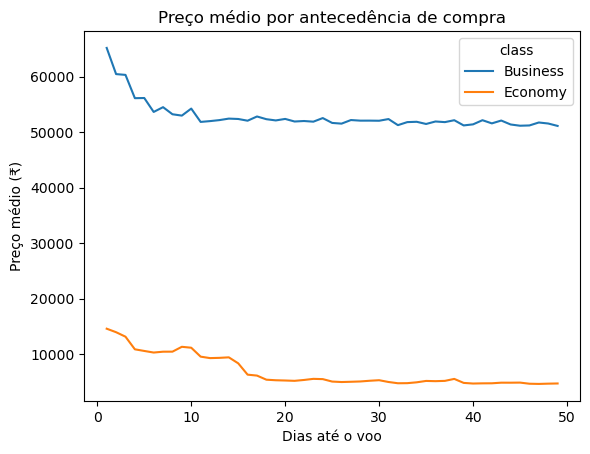

In [20]:
sns.lineplot(data=media_por_dia, x='days_left', y='price', hue='class')
plt.title('Preço médio por antecedência de compra')
plt.xlabel('Dias até o voo')
plt.ylabel('Preço médio (₹)')
plt.show()

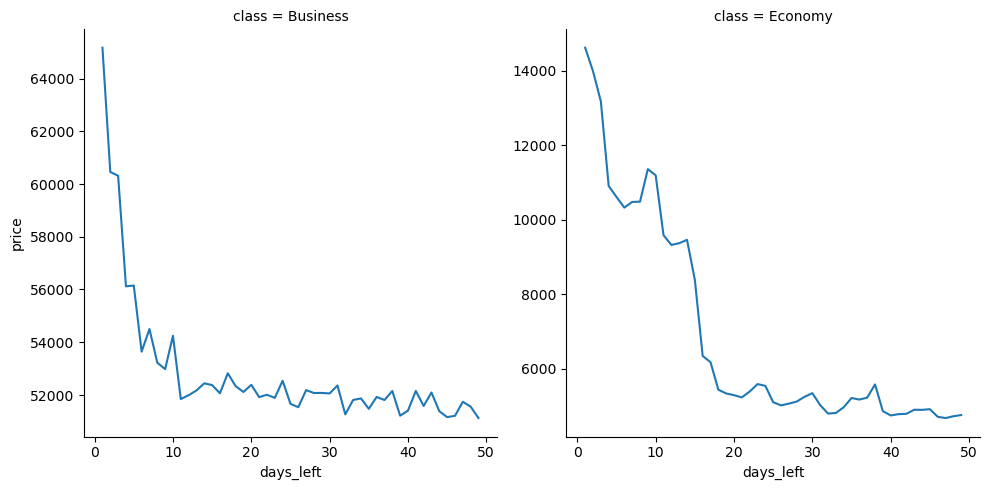

In [21]:
sns.relplot(
    data=media_por_dia,
    x='days_left', y='price',
    col='class',
    kind='line',
    facet_kws={'sharey': False}
)
plt.show()

### Conclusão: `days_left` × `price`

A hipótese inicial do plano era uma curva em "U" (preço alto tanto perto quanto muito distante do voo, com um mínimo intermediário). Os dados **não confirmam essa hipótese**: o padrão observado, tanto em Economy quanto em Business, é uma **curva de decaimento** — queda acentuada de preço nos primeiros dias de antecedência, seguida de estabilização a partir de ~15-20 dias, sem voltar a subir nos dias mais distantes.

Mesmo separando as classes em escalas independentes (para evitar que a faixa de preço da Business "esmague" visualmente a da Economy), o formato se mantém: decaimento acentuado + platô. Ambas as curvas também exibem uma pequena saliência não-monotônica por volta dos dias 8-11, provavelmente ruído (menos voos vendidos com tanta antecedência gera médias mais instáveis), mas que reforça o ponto central.

**Por que isso importa:** mesmo sem o formato de "U", a relação continua fortemente não-linear. Uma regressão linear, ao tentar ajustar uma reta única a essa curva, subestimaria sistematicamente os preços de compra de última hora (onde a queda é mais íngreme) e teria dificuldade em capturar o platô nos dias mais distantes — exatamente o tipo de comportamento que modelos baseados em árvore (Random Forest, Gradient Boosting, XGBoost) capturam naturalmente, sem precisar de transformações manuais (como teria que ser feito para "linearizar" a curva numa regressão linear).

## Boxplot

In [23]:
ordem = df_clean.groupby('airline')['price'].median().sort_values().index

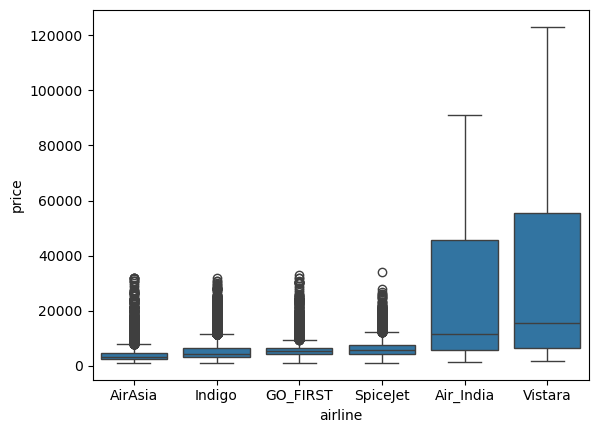

In [30]:
sns.boxplot(data=df_clean, x='airline', y='price', order=ordem)
plt.show()

### Nota: `airline` × `price`

As companhias `Air_India` e `Vistara` apresentam uma variação de preço muito maior (caixas grandes, indo de valores baixos até acima de 120.000) comparadas às outras quatro (`AirAsia`, `Indigo`, `GO_FIRST`, `SpiceJet`), que ficam concentradas em faixas baixas e estreitas.

O motivo não é que essas duas companhias sejam "inconsistentes" — é que `Air_India` e `Vistara` são as únicas que oferecem assento **Business** além de Economy, enquanto as outras operam só como low-cost/Economy. O boxplot delas mistura dois patamares de preço bem diferentes numa única caixa.

**Implicação:** `airline` sozinha não é uma boa preditora de `price` — o que importa é a **interação** entre `airline` e `class`. Isso é exatamente o tipo de padrão que uma regressão linear simples não capturaria bem (a menos que se criasse manualmente uma feature de interação), mas que modelos de árvore capturam naturalmente ao dividir os dados recursivamente por múltiplas colunas.

In [31]:
ordem = df_clean.groupby('stops')['price'].median().sort_values().index

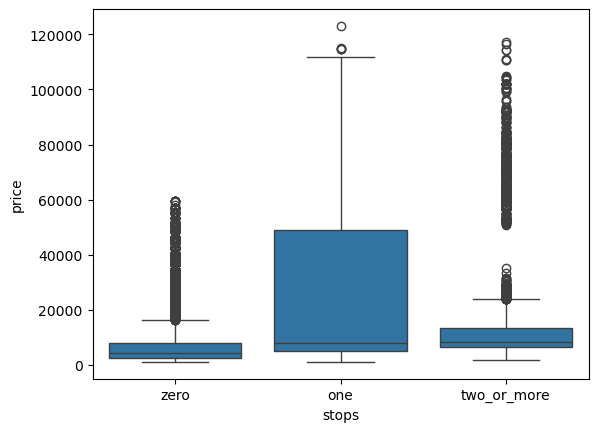

In [33]:
sns.boxplot(data=df_clean, x='stops', y='price', order=ordem)
plt.show()

In [34]:
pd.crosstab(df_clean['stops'], df_clean['class'])

class,Business,Economy
stops,,
one,84302,166561
two_or_more,1083,12203
zero,8102,27902


### Nota: `stops` × `price`

O padrão observado no boxplot é contraintuitivo à primeira vista: voos com uma escala (`one`) apresentam mediana e dispersão de preço maiores que voos diretos (`zero`) e até maiores que voos com duas ou mais escalas (`two_or_more`) — o oposto do que se esperaria supondo que "menos escalas = rota mais direta = mais caro".

Verificando a distribuição de `class` dentro de cada grupo de `stops` (`pd.crosstab`), a explicação aparece: a proporção de assentos **Business** varia muito entre os grupos — `one stop` tem ~34% Business, `zero stops` tem ~22,5%, e `two_or_more` tem só ~8,2%. Como Business custa muito mais que Economy, um grupo com mais concentração de Business puxa a mediana pra cima, independente do número de escalas em si.

**Implicação:** assim como `airline`, a variável `stops` também tem seu efeito sobre `price` contaminado pela interação com `class`. Reforça o mesmo ponto: essas variáveis não devem ser interpretadas isoladamente, e um modelo que capture interações entre features (como árvores de decisão) tem vantagem sobre um modelo linear simples que trataria cada variável de forma aditiva/independente.

In [35]:
ordem = df_clean.groupby('departure_time')['price'].median().sort_values().index

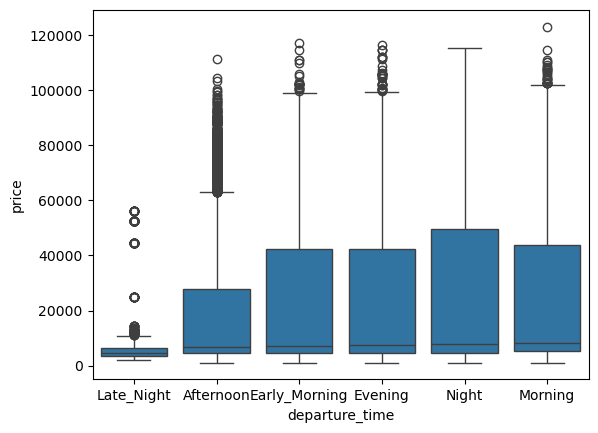

In [36]:
sns.boxplot(data=df_clean, x='departure_time', y='price', order=ordem)
plt.show()

In [37]:
pd.crosstab(df_clean['departure_time'], df_clean['class'])

class,Business,Economy
departure_time,,
Afternoon,12549,35245
Early_Morning,20102,46688
Evening,20895,44207
Late_Night,138,1168
Morning,22325,48821
Night,17478,30537


In [38]:
df_economy = df_clean[df_clean['class'] == 'Economy']

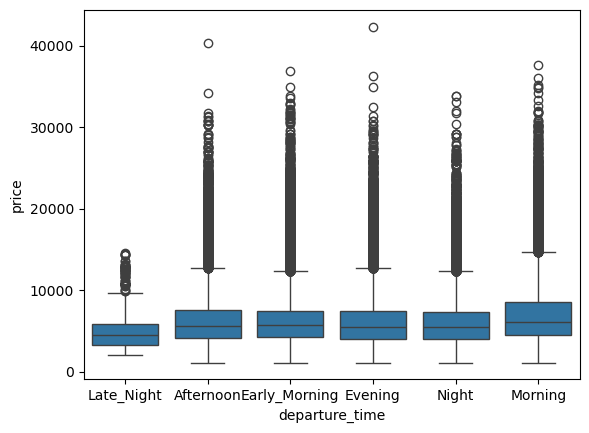

In [42]:
sns.boxplot(data=df_economy, x='departure_time', y='price', order=ordem)
plt.show()

### Nota: `departure_time` × `price` (com investigação extra)

No boxplot geral, `Late_Night` aparece com preço muito mais baixo que os outros períodos do dia. A primeira hipótese testada foi a mesma dos casos anteriores: será que é só o efeito de `class` contaminando a variável (menos assentos Business em voos de madrugada)?

O crosstab confirmou parte da hipótese: `Late_Night` tem apenas ~10,6% de assentos Business, contra 26%-36% nos outros períodos — e também é a categoria mais rara (1.306 voos, muito menos que os outros).

Para isolar esse efeito, o boxplot foi refeito **filtrando só voos Economy**. Resultado: `Late_Night` continua com mediana e dispersão menores que os outros horários, mas a diferença fica bem mais sutil que no gráfico original.

**Conclusão:** a maior parte da diferença observada inicialmente era explicada pela composição de `class`, mas sobra um efeito residual real de horário — voos de madrugada são genuinamente um pouco mais baratos, provavelmente por menor demanda nesse horário. Isso mostra a importância de checar variáveis de confusão antes de interpretar um padrão como causal.

In [43]:
mapa_stops = {'zero': 0, 'one': 1, 'two_or_more': 2}
df_clean['stops_num'] = df_clean['stops'].map(mapa_stops)

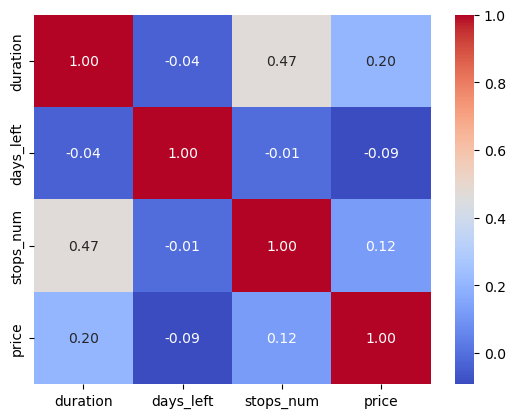

In [44]:
colunas = ['duration', 'days_left', 'stops_num', 'price']
matriz_corr = df_clean[colunas].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## Conclusões da EDA

A exploração revelou múltiplos padrões não-lineares e interações entre variáveis que motivam o uso de modelos baseados em árvore em vez de regressão linear:

**1. `days_left` × `price` — relação de decaimento, não linear**
Em vez do "U" hipotetizado inicialmente, os dados mostram uma curva de decaimento acentuado nos primeiros dias de antecedência, seguida de estabilização. O achado mais revelador: a correlação de Pearson entre `days_left` e `price` é de apenas **-0,09**, quase nula — apesar da relação ser visualmente forte e óbvia no gráfico. Isso acontece porque a correlação de Pearson só mede relações **lineares**, e essa relação é uma curva acentuada que "engana" o coeficiente. É a evidência mais concreta do projeto de que um modelo linear falharia aqui, mesmo quando os dados brutos sugerem o contrário à primeira vista.

**2. `airline` × `class` — efeito de interação, não efeito isolado**
`Air_India` e `Vistara` mostram variação de preço muito maior que as demais companhias — não porque sejam inconsistentes, mas porque são as únicas que oferecem assento Business além de Economy. O efeito de `airline` sobre `price` está entrelaçado com `class`.

**3. `stops` × `class` — mesmo padrão de contaminação**
Voos com uma escala (`one stop`) têm preço mediano maior que voos diretos, contraintuitivamente. A causa: `one stop` tem proporção de assentos Business (~34%) bem maior que voos diretos (~22,5%) ou com múltiplas escalas (~8,2%). De novo, o efeito de `stops` isolado não conta a história completa.

**4. `departure_time` — efeito real, mas menor do que parecia**
Voos de madrugada (`Late_Night`) aparecem bem mais baratos no boxplot geral. Ao isolar o efeito filtrando só Economy, a diferença de preço diminui bastante mas não desaparece — a maior parte do efeito original era composição de `class` (menos Business de madrugada), mas sobra um efeito residual real: voos de madrugada são genuinamente um pouco mais baratos, provavelmente por menor demanda.

**Conclusão geral:** o dataset é dominado por relações não-lineares (`days_left`) e efeitos de interação entre variáveis categóricas (`airline`, `stops`, `departure_time` com `class`). Uma regressão linear, que assume aditividade e linearidade, tende a errar sistematicamente nesses padrões — sem engenharia manual de features de interação e transformações não-lineares. Modelos baseados em árvore (Random Forest, Gradient Boosting, XGBoost) capturam esses padrões nativamente, sem exigir esse trabalho manual, o que motiva diretamente a progressão do projeto: Linear → Random Forest → GBM → XGBoost.

# Preparação dos dados e baseline linear

In [62]:
# Passo 1 — Definir features e target
X = df_clean.drop(columns=['Unnamed: 0', 'flight', 'stops', 'price'])
y = df_clean['price']

In [63]:
X.columns

Index(['airline', 'source_city', 'departure_time', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'stops_num'],
      dtype='object')

In [66]:
#Passo 2 — One-Hot Encoding
X_encoded = pd.get_dummies(X)

In [65]:
X_encoded.shape

(300153, 35)

In [67]:
X_encoded.head()

,duration,days_left,stops_num,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Bangalore,...,arrival_time_Morning,arrival_time_Night,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Business,class_Economy
0,2.17,1,0,False,False,False,False,True,False,False,...,False,True,False,False,False,False,False,True,False,True
1,2.33,1,0,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,True,False,True
2,2.17,1,0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2.25,1,0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,True
4,2.33,1,0,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,True,False,True


In [68]:
#Passo 3 — Split treino/teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [69]:
X_train.shape

(240122, 35)

In [70]:
X_test.shape

(60031, 35)

In [71]:
#Passo 4 — Treinar a Regressão Linear
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
pred_train = modelo_linear.predict(X_train)
pred_test = modelo_linear.predict(X_test)

In [73]:
#Passo 5 - Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_train = mean_absolute_error(y_train, pred_train)
mse_train = mean_squared_error(y_train, pred_train)
rmse_train = mse_train ** 0.5
r2_train = r2_score(y_train, pred_train)

mae_test = mean_absolute_error(y_test, pred_test)
mse_test = mean_squared_error(y_test, pred_test)
rmse_test = mse_test ** 0.5
r2_test = r2_score(y_test, pred_test)

print(f"Treino -> MAE: {mae_train:.2f} | RMSE: {rmse_train:.2f} | R²: {r2_train:.4f}")
print(f"Teste  -> MAE: {mae_test:.2f} | RMSE: {rmse_test:.2f} | R²: {r2_test:.4f}")

Treino -> MAE: 4525.84 | RMSE: 6808.90 | R²: 0.9100
Teste  -> MAE: 4500.71 | RMSE: 6814.94 | R²: 0.9099


In [76]:
y.mean()

np.float64(20889.660523133203)

In [77]:
y.std()

22697.767366075885

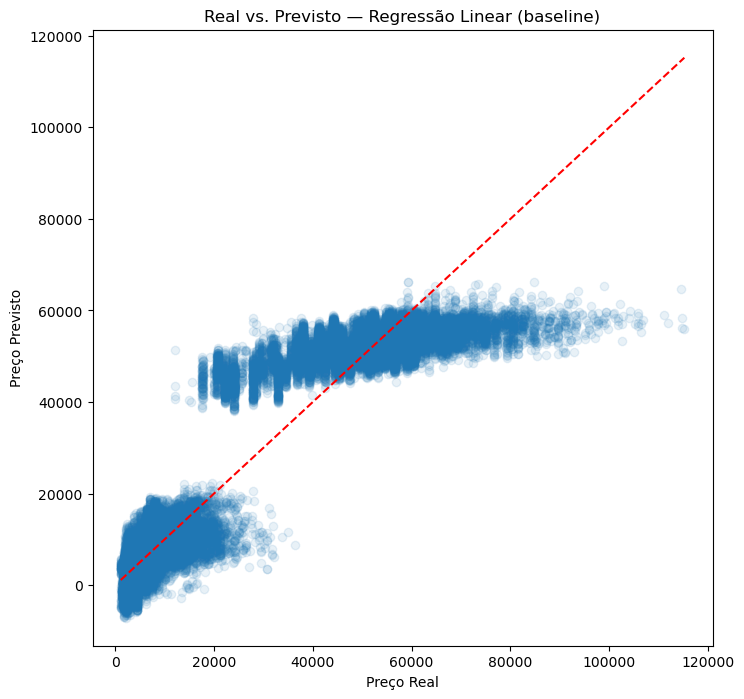

In [78]:
#Passo 6 — Gráfico Real vs. Previsto
plt.figure(figsize=(8,8))
plt.scatter(y_test, pred_test, alpha=0.1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Real vs. Previsto — Regressão Linear (baseline)')
plt.show()

In [79]:
resultados = {
    'Regressão Linear': {
        'MAE Treino': mae_train, 'RMSE Treino': rmse_train, 'R² Treino': r2_train,
        'MAE Teste': mae_test, 'RMSE Teste': rmse_test, 'R² Teste': r2_test
    }
}

In [82]:
pd.DataFrame(resultados).T

,MAE Treino,RMSE Treino,R² Treino,MAE Teste,RMSE Teste,R² Teste
Regressão Linear,4525.843785,6808.899898,0.909998,4500.712502,6814.935635,0.909903


## Conclusões: Baseline Linear

O modelo de Regressão Linear treinado como baseline obteve:

| Conjunto | MAE | RMSE | R² |
|---|---|---|---|
| Treino | 4525,84 | 6808,90 | 0,9100 |
| Teste | 4500,71 | 6814,94 | 0,9099 |

À primeira vista, o R² de ~0,91 parece um resultado forte, e a diferença mínima entre treino e teste confirma que **não há overfitting** — o modelo generaliza bem, mas está limitado pela sua própria capacidade (não pela memorização dos dados de treino).

Porém, esse R² alto é enganoso: ele é inflado principalmente pela capacidade do modelo de capturar a diferença de preço entre `class` (Economy vs. Business), que é um salto grande e quase categórico — algo que até um modelo linear consegue captar bem via One-Hot Encoding. O MAE de ~4500, quando comparado à média de `price` (~20.889), representa um erro médio de ~21,6% — bem mais alto do que o R² sugeriria isoladamente.

O gráfico Real vs. Previsto expõe o problema com mais clareza: os pontos se dividem visivelmente em dois aglomerados (Economy embaixo, Business em cima), mas **dentro de cada aglomerado, especialmente na Business**, o modelo erra sistematicamente — voos Business caros (>60.000) são subestimados, e voos Business baratos (~20.000-30.000) são superestimados. O modelo não consegue diferenciar bem os preços dentro de uma mesma classe, porque essas variações dependem de relações não-lineares (`days_left`) e interações entre variáveis que a regressão linear não consegue capturar sem engenharia manual de features.

**Conclusão:** o modelo linear captura o efeito grosseiro de `class`, mas falha nos padrões mais sutis identificados na EDA — exatamente a motivação para avançar para modelos baseados em árvore, que capturam não-linearidades e interações nativamente.

# Random Forest

In [83]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
pred_train_rf = modelo_rf.predict(X_train)
pred_test_rf = modelo_rf.predict(X_test)

In [85]:
mae_train_rf = mean_absolute_error(y_train, pred_train_rf)
rmse_train_rf = mean_squared_error(y_train, pred_train_rf) ** 0.5
r2_train_rf = r2_score(y_train, pred_train_rf)

mae_test_rf = mean_absolute_error(y_test, pred_test_rf)
rmse_test_rf = mean_squared_error(y_test, pred_test_rf) ** 0.5
r2_test_rf = r2_score(y_test, pred_test_rf)

resultados['Random Forest'] = {
    'MAE Treino': mae_train_rf, 'RMSE Treino': rmse_train_rf, 'R² Treino': r2_train_rf,
    'MAE Teste': mae_test_rf, 'RMSE Teste': rmse_test_rf, 'R² Teste': r2_test_rf
}

print(f"Treino -> MAE: {mae_train_rf:.2f} | RMSE: {rmse_train_rf:.2f} | R²: {r2_train_rf:.4f}")
print(f"Teste  -> MAE: {mae_test_rf:.2f} | RMSE: {rmse_test_rf:.2f} | R²: {r2_test_rf:.4f}")

Treino -> MAE: 416.06 | RMSE: 1119.92 | R²: 0.9976
Teste  -> MAE: 1075.49 | RMSE: 2782.56 | R²: 0.9850


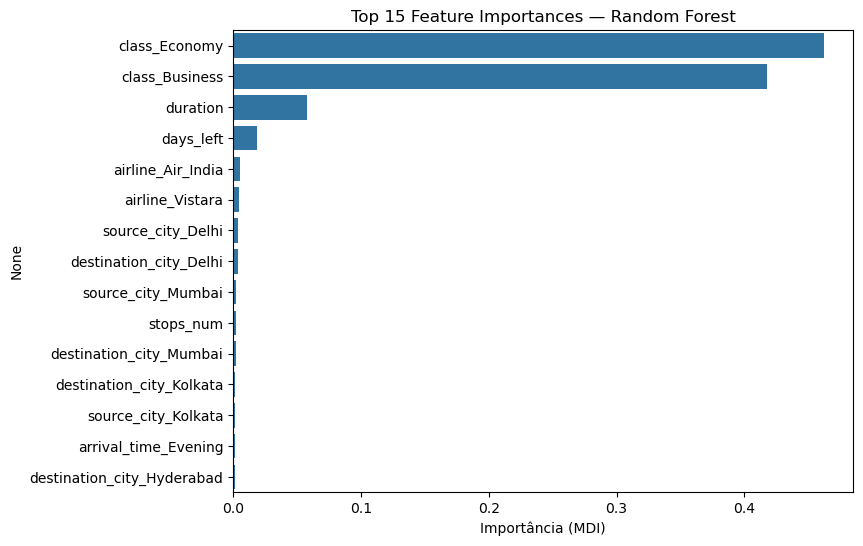

In [86]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)
top15 = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top15.values, y=top15.index)
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importância (MDI)')
plt.show()

## Conclusões: Random Forest

O Random Forest usa **Bagging** (Bootstrap Aggregating): em vez de uma única árvore, treina centenas de árvores independentes (aqui, 200), cada uma vendo uma amostra aleatória dos dados (com reposição) e um subconjunto aleatório de features em cada divisão. A previsão final é a média das árvores, o que reduz a variância em relação a uma única árvore profunda, já que os erros individuais tendem a se cancelar.

**Resultados:**

| Conjunto | MAE | RMSE | R² |
|---|---|---|---|
| Treino | 416,06 | 1119,92 | 0,9976 |
| Teste | 1075,49 | 2782,56 | 0,9850 |

Melhora expressiva em relação à Regressão Linear: MAE no teste caiu de ~4500 para ~1075, e R² subiu de 0,9099 para 0,9850. Isso confirma a hipótese da EDA — um modelo capaz de capturar não-linearidades e interações performa muito melhor nesse problema.

Diferente do baseline linear (que não tinha gap treino/teste), o Random Forest apresenta **overfitting visível**: o desempenho no treino é bem superior ao do teste. Isso acontece porque, por padrão, `max_depth=None` — cada árvore pode crescer sem limite, ajustando-se muito de perto (às vezes até demais) aos dados de treino. O Bagging reduz esse overfitting comparado a uma única árvore profunda, mas não o elimina — controlar `max_depth` seria o próximo passo natural para reduzir esse gap, embora fora do escopo deste projeto introdutório.

**Feature Importance (MDI):** `class_Economy`/`class_Business` dominam o ranking de importância, seguidas de `duration` e, só em 4º lugar, `days_left` — mesmo sendo a relação mais visualmente marcante da EDA. Isso expõe uma limitação do MDI: ele mede o quanto cada variável reduz o erro em valor absoluto nas divisões onde é usada, então uma variável com efeito de grande magnitude (`class`, com diferenças de dezenas de milhares de rúpias) domina o ranking, mesmo que outra variável (`days_left`) tenha um padrão genuíno e não-linear, só que de magnitude menor. O MDI não conta a história completa — uma alternativa mais robusta seria a `permutation_importance`, fora do escopo deste projeto.

# Gradient Boosting (sklearn)

In [87]:
from sklearn.ensemble import GradientBoostingRegressor

modelo_gbm = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
modelo_gbm.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [88]:
pred_train_gbm = modelo_gbm.predict(X_train)
pred_test_gbm = modelo_gbm.predict(X_test)

mae_train_gbm = mean_absolute_error(y_train, pred_train_gbm)
rmse_train_gbm = mean_squared_error(y_train, pred_train_gbm) ** 0.5
r2_train_gbm = r2_score(y_train, pred_train_gbm)

mae_test_gbm = mean_absolute_error(y_test, pred_test_gbm)
rmse_test_gbm = mean_squared_error(y_test, pred_test_gbm) ** 0.5
r2_test_gbm = r2_score(y_test, pred_test_gbm)

resultados['Gradient Boosting'] = {
    'MAE Treino': mae_train_gbm, 'RMSE Treino': rmse_train_gbm, 'R² Treino': r2_train_gbm,
    'MAE Teste': mae_test_gbm, 'RMSE Teste': rmse_test_gbm, 'R² Teste': r2_test_gbm
}

print(f"Treino -> MAE: {mae_train_gbm:.2f} | RMSE: {rmse_train_gbm:.2f} | R²: {r2_train_gbm:.4f}")
print(f"Teste  -> MAE: {mae_test_gbm:.2f} | RMSE: {rmse_test_gbm:.2f} | R²: {r2_test_gbm:.4f}")

Treino -> MAE: 2595.45 | RMSE: 4417.16 | R²: 0.9621
Teste  -> MAE: 2618.50 | RMSE: 4488.05 | R²: 0.9609


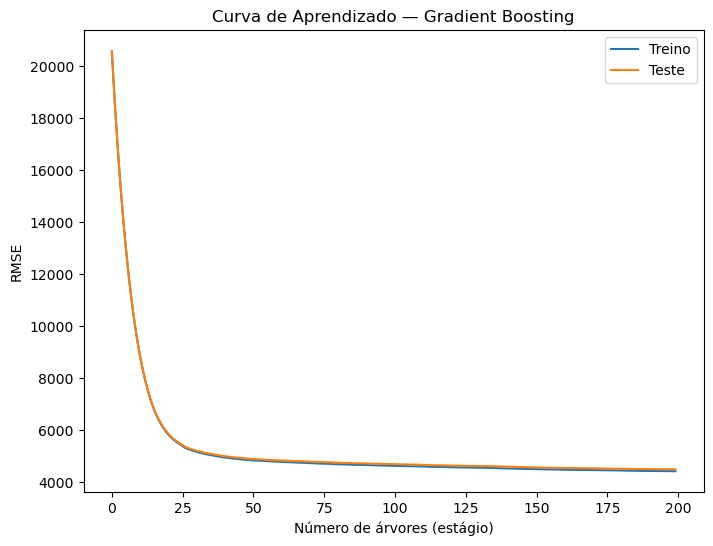

In [89]:
rmse_treino_por_estagio = []
rmse_teste_por_estagio = []

for pred_train_stage, pred_test_stage in zip(modelo_gbm.staged_predict(X_train), modelo_gbm.staged_predict(X_test)):
    rmse_treino_por_estagio.append(mean_squared_error(y_train, pred_train_stage) ** 0.5)
    rmse_teste_por_estagio.append(mean_squared_error(y_test, pred_test_stage) ** 0.5)

plt.figure(figsize=(8,6))
plt.plot(rmse_treino_por_estagio, label='Treino')
plt.plot(rmse_teste_por_estagio, label='Teste')
plt.xlabel('Número de árvores (estágio)')
plt.ylabel('RMSE')
plt.title('Curva de Aprendizado — Gradient Boosting')
plt.legend()
plt.show()

## Conclusões: Gradient Boosting

O Gradient Boosting usa uma filosofia diferente do Random Forest: em vez de árvores independentes treinadas em paralelo (Bagging), o Boosting treina árvores **sequencialmente**, onde cada nova árvore tenta corrigir os resíduos (erros) deixados pelas árvores anteriores. O `learning_rate` (aqui, 0,1) controla o "shrinkage" — o quanto cada árvore nova contribui pra correção, funcionando como um freio contra overfitting: valores baixos exigem mais árvores, mas tornam o aprendizado mais estável.

**Resultados:**

| Conjunto | MAE | RMSE | R² |
|---|---|---|---|
| Treino | 2595,45 | 4417,16 | 0,9621 |
| Teste | 2618,50 | 4488,05 | 0,9609 |

Contrariando a expectativa inicial de que Boosting tende a superar Bagging, o GBM performou **pior** que o Random Forest nesse caso (R² 0,9609 vs. 0,9850 no teste). O motivo não é uma falha do Boosting como técnica — é a combinação de hiperparâmetros conservadores: `max_depth=4` (árvores rasas) e apenas 200 estimadores limitaram a capacidade do modelo de se ajustar tão profundamente quanto o RF (que usa `max_depth=None`). Em compensação, o GBM praticamente não apresenta overfitting: as métricas de treino e teste ficam muito próximas, ao contrário do gap visível no Random Forest.

**Curva de Aprendizado:** usando `staged_predict`, foi possível visualizar o RMSE em função do número de árvores. As curvas de treino e teste ficam praticamente sobrepostas do início ao fim, confirmando a ausência de overfitting. Porém, no estágio final (200 árvores), a curva ainda estava em leve queda — sinal de que o modelo não tinha convergido totalmente, e mais árvores (ou um `learning_rate` maior) provavelmente melhorariam o desempenho sem risco imediato de overfitting, já que as curvas não mostram sinal de divergência.

**Conclusão:** o Gradient Boosting, apesar de tecnicamente superior em conceito, ficou aquém do Random Forest nesse experimento por causa dos hiperparâmetros escolhidos — um lembrete de que "Boosting > Bagging" não é uma regra absoluta, depende de como cada modelo é configurado. Isso motiva o próximo passo do projeto: o XGBoost, que costuma extrair mais desempenho do Boosting de forma mais eficiente.

# XGBoost

In [91]:
import xgboost

In [92]:
from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, tree_method='hist')
modelo_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [93]:
pred_train_xgb = modelo_xgb.predict(X_train)
pred_test_xgb = modelo_xgb.predict(X_test)

mae_train_xgb = mean_absolute_error(y_train, pred_train_xgb)
rmse_train_xgb = mean_squared_error(y_train, pred_train_xgb) ** 0.5
r2_train_xgb = r2_score(y_train, pred_train_xgb)

mae_test_xgb = mean_absolute_error(y_test, pred_test_xgb)
rmse_test_xgb = mean_squared_error(y_test, pred_test_xgb) ** 0.5
r2_test_xgb = r2_score(y_test, pred_test_xgb)

resultados['XGBoost'] = {
    'MAE Treino': mae_train_xgb, 'RMSE Treino': rmse_train_xgb, 'R² Treino': r2_train_xgb,
    'MAE Teste': mae_test_xgb, 'RMSE Teste': rmse_test_xgb, 'R² Teste': r2_test_xgb
}

print(f"Treino -> MAE: {mae_train_xgb:.2f} | RMSE: {rmse_train_xgb:.2f} | R²: {r2_train_xgb:.4f}")
print(f"Teste  -> MAE: {mae_test_xgb:.2f} | RMSE: {rmse_test_xgb:.2f} | R²: {r2_test_xgb:.4f}")

Treino -> MAE: 1902.09 | RMSE: 3328.41 | R²: 0.9785
Teste  -> MAE: 1960.02 | RMSE: 3462.81 | R²: 0.9767


<Figure size 800x600 with 0 Axes>

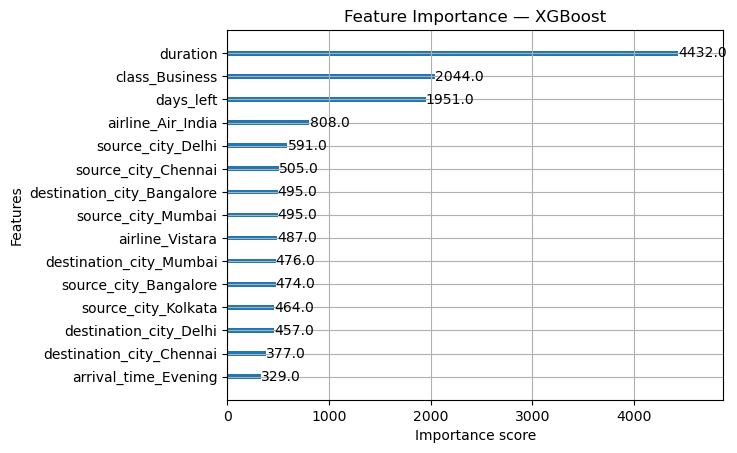

In [94]:
from xgboost import plot_importance

plt.figure(figsize=(8,6))
plot_importance(modelo_xgb, max_num_features=15, importance_type='weight')
plt.title('Feature Importance — XGBoost')
plt.show()

## Conclusões: XGBoost

O XGBoost é uma implementação otimizada de Gradient Boosting que adiciona, entre outras melhorias: **regularização L1/L2 nativa** (`reg_alpha`/`reg_lambda`), que penaliza a complexidade das árvores e ajuda a controlar overfitting diretamente no processo de treinamento; tratamento nativo de valores ausentes; e paralelismo na construção das árvores. O parâmetro `tree_method='hist'` usado aqui agrupa valores contínuos em histogramas para acelerar a busca por splits, tornando o treinamento bem mais rápido em datasets grandes como este (~240k linhas) — é por isso que o XGBoost é o modelo padrão em competições Kaggle: bom equilíbrio entre performance e velocidade.

**Resultados:**

| Conjunto | MAE | RMSE | R² |
|---|---|---|---|
| Treino | 1902,09 | 3328,41 | 0,9785 |
| Teste | 1960,02 | 3462,81 | 0,9767 |

O XGBoost superou claramente o Gradient Boosting clássico (R² 0,9767 vs. 0,9609 no teste), confirmando o ganho esperado da regularização e maior capacidade (`max_depth=6`, 300 árvores). Também apresentou um gap treino/teste bem menor que o Random Forest (0,9785 vs. 0,9767, contra 0,9976 vs. 0,9850 do RF) — evidência de que a regularização nativa está de fato controlando o overfitting de forma mais eficaz.

**Achado contraintuitivo:** apesar de tudo isso, o XGBoost **não superou o Random Forest** no teste (MAE 1960 vs. 1075; R² 0,9767 vs. 0,9850). Isso contraria a expectativa inicial de que XGBoost seria "geralmente o melhor". A explicação mais provável não é que o Boosting regularizado seja inferior ao Bagging — é que, com os hiperparâmetros fixos usados neste projeto (sem tuning), o Random Forest por acaso se encaixou melhor neste dataset específico. Com otimização de hiperparâmetros, é esperado que o XGBoost supere o RF — mas isso está fora do escopo deste projeto introdutório, focado em entender os conceitos, não em maximizar performance via tuning.

**Feature Importance (`weight`):** a ordem de importância aqui (`duration` > `class_Business` > `days_left`) é bem diferente da do Random Forest, onde `class` dominava sozinha quase 90% da importância. O motivo é que `weight` conta **quantas vezes** cada variável foi usada para dividir uma árvore, não o quanto cada divisão reduziu o erro (que é o que o MDI mede). Como `duration` é uma variável contínua com muitos valores possíveis, ela é escolhida para split com muito mais frequência que `class` (que é binária e só tem um jeito de dividir), mesmo que cada divisão por `class` tenha impacto individual maior. Isso reforça a lição da Sub-Tarefa 4: nenhuma métrica de importância conta a história completa — cada uma mede um aspecto diferente do papel da variável no modelo.

# Comparações finais

In [95]:
df_resultados = pd.DataFrame(resultados).T
df_resultados

,MAE Treino,RMSE Treino,R² Treino,MAE Teste,RMSE Teste,R² Teste
Regressão Linear,4525.843785,6808.899898,0.909998,4500.712502,6814.935635,0.909903
Random Forest,416.057083,1119.919174,0.997565,1075.486172,2782.560293,0.984980
Gradient Boosting,2595.449539,4417.155962,0.962122,2618.496150,4488.047223,0.960925
XGBoost,1902.090454,3328.408929,0.978493,1960.023071,3462.808253,0.976738


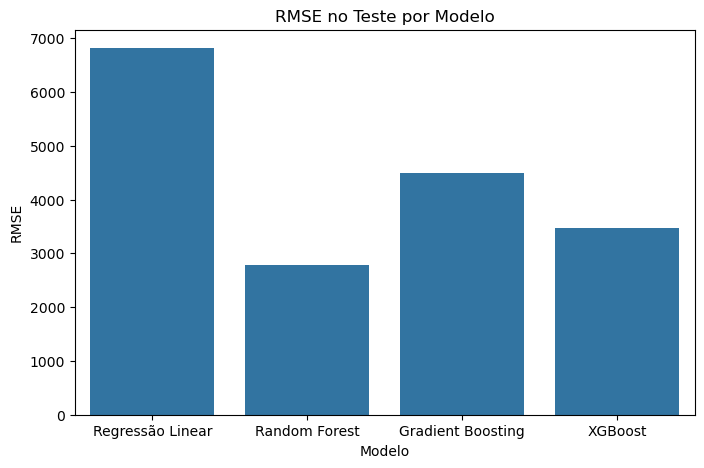

In [97]:
plt.figure(figsize=(8,5))
sns.barplot(x=df_resultados.index, y=df_resultados['RMSE Teste'])
plt.title('RMSE no Teste por Modelo')
plt.ylabel('RMSE')
plt.xlabel('Modelo')
plt.show()

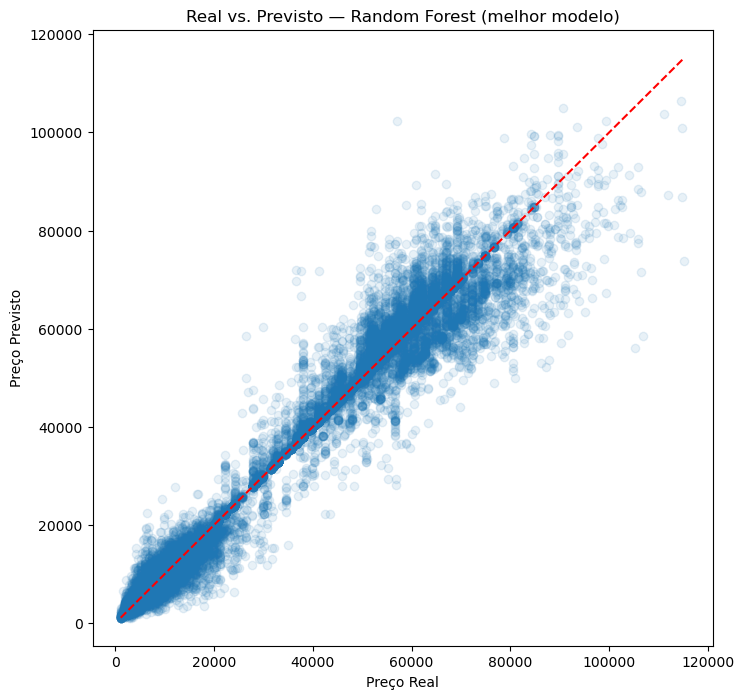

In [96]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, pred_test_rf, alpha=0.1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Real vs. Previsto — Random Forest (melhor modelo)')
plt.show()

## Conclusões Finais

### Tabela Comparativa

| Modelo | MAE Treino | RMSE Treino | R² Treino | MAE Teste | RMSE Teste | R² Teste |
|---|---|---|---|---|---|---|
| Regressão Linear | 4525,84 | 6808,90 | 0,9100 | 4500,71 | 6814,94 | 0,9099 |
| Random Forest | 416,06 | 1119,92 | 0,9976 | 1075,49 | 2782,56 | **0,9850** |
| Gradient Boosting | 2595,45 | 4417,16 | 0,9621 | 2618,50 | 4488,05 | 0,9609 |
| XGBoost | 1902,09 | 3328,41 | 0,9785 | 1960,02 | 3462,81 | 0,9767 |

### Qual modelo venceu, e por quê

O **Random Forest** teve o melhor desempenho no teste (menor MAE e RMSE, maior R²), superando inclusive o XGBoost — um resultado que contraria a expectativa inicial de que o XGBoost seria "o estado da arte" nesta comparação. A explicação não é que Bagging seja superior a Boosting regularizado de forma geral: é que, com os hiperparâmetros fixos usados neste projeto (sem tuning), o RF (árvores profundas sem limite, `max_depth=None`) se encaixou melhor neste dataset específico que o XGBoost (`max_depth=6`) e o GBM (`max_depth=4`, o pior dos quatro, limitado demais). Isso é uma lição prática importante: a superioridade teórica de um algoritmo não garante o melhor resultado sem ajuste de hiperparâmetros — o Random Forest, mesmo sendo conceitualmente mais simples, ganhou "por W.O." dado o setup usado.

### Conectando de volta à EDA

- A **Regressão Linear** (R² 0,9099) captou bem apenas o efeito grosseiro de `class` (Economy vs. Business), mas falhou nas variações finas dentro de cada classe — visível no gráfico Real vs. Previsto, onde os preços Business ficavam comprimidos numa faixa estreita independente do valor real.
- Isso confirma a hipótese levantada na EDA: a correlação de Pearson quase nula entre `days_left` e `price` (-0,09) escondia uma relação não-linear forte (curva de decaimento), que só os modelos de árvore conseguiram captar.
- Os efeitos de interação identificados na EDA (`airline`×`class`, `stops`×`class`) também são exatamente o tipo de padrão que árvores capturam nativamente ao dividir os dados recursivamente por múltiplas variáveis — e que uma regressão linear simples, sem features de interação manuais, não capta.
- O gráfico Real vs. Previsto do Random Forest mostra os pontos aderindo de perto à diagonal em toda a faixa de preços, confirmando visualmente a superação do problema identificado na Sub-Tarefa 3.

### O que cada conceito explicou

- **Bagging (Random Forest)** reduziu a variância ao promediar centenas de árvores independentes, mas ainda apresentou overfitting visível por não limitar `max_depth`.
- **Boosting (Gradient Boosting, XGBoost)** ajustou-se sequencialmente aos resíduos; a curva de aprendizado do GBM mostrou convergência ainda incompleta aos 200 estágios, e o `learning_rate` funcionou como controle de velocidade/estabilidade do aprendizado.
- **Regularização L1/L2 nativa do XGBoost** controlou o overfitting de forma mais eficaz que qualquer outro modelo (menor gap treino/teste), mesmo sem vencer em erro absoluto.
- **Feature Importance** teve leituras diferentes dependendo da métrica: o MDI (Random Forest) destacou `class` isoladamente por seu impacto de grande magnitude, enquanto o `weight` (XGBoost) destacou `duration` por frequência de uso — nenhuma das duas contando a história completa sozinha.

### Próximos passos (fora do escopo deste projeto)
- Tuning de hiperparâmetros (`GridSearchCV`/`RandomizedSearchCV`) para verificar se XGBoost supera o Random Forest com ajuste adequado.
- `permutation_importance` para uma leitura mais robusta da relevância das features.
- Engenharia de features de interação explícitas para tentar melhorar a Regressão Linear como comparação mais justa.